# Week 6 - Baseline Model of an Explainable AI Assistant to Support Emergency Department Triage

**Author**: Sariana Ramoutar

This notebook develops baseline machine learning models to predict Emergency Severity Index (ESI) levels using emergency department triage data.

The workflow follows good machine learning practice by:
- loading and preparing the data
- preventing data leakage
- splitting the data into training and testing sets
- training baseline classifiers
- evaluating model performance
- comparing against a random baseline
- exploring model interpretability using Explainable AI principles.

## 1. Setting Up the Workspace

In [1]:
# Import necessary libraries for data handling, plotting, and file operations.
import os # For interacting with the operating system, e.g., creating directories.
import pandas as pd # For data manipulation and analysis using DataFrames.
import numpy as np # For numerical operations.
import matplotlib.pyplot as plt # For creating static, interactive, and animated visualisations.
import seaborn as sns # For making attractive and informative statistical graphics.

In [2]:
# Set pandas display options to ensure that DataFrames are fully visible and easy to read.
# 'display.max_columns = None' ensures all columns are shown.
# 'display.max_rows = 100' ensures up to 100 rows are shown before truncation.
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [3]:
# Define the folder names for storing figures (plots) and trained models.
FIGS_FOLDER = 'figs'
MODELS_FOLDER = 'models'

# Create the 'figs' folder if it does not already exist.
# This ensures a place to save any visualisations generated.
if not os.path.exists(FIGS_FOLDER):
    os.makedirs(FIGS_FOLDER)
    print(f"Created folder: {FIGS_FOLDER}/")

# Create the 'models' folder if it does not already exist.
# This ensures a place to save any machine learning models trained later.
if not os.path.exists(MODELS_FOLDER):
    os.makedirs(MODELS_FOLDER)
    print(f"Created folder: {MODELS_FOLDER}/")

Created folder: figs/
Created folder: models/


## 2. Loading the Patient Data

In [4]:
# Mount Google Drive to allow this Colab notebook to access files stored in your Drive.
# A pop-up will appear asking for authentication to connect to your Google Drive.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Define the file path for the cleaned CSV dataset in Google Drive.
FILE_PATH = '/content/drive/MyDrive/CariSurg Documents/yaleemmlc_admissionprediction_triage.csv'

# Load the cleaned CSV file into a pandas DataFrame.
# This dataset is expected to be pre-processed and ready for modelling.
triage_df = pd.read_csv(FILE_PATH)

# Print a confirmation message to indicate successful data loading.
print(f"Successfully loaded data from: {FILE_PATH}")

Successfully loaded data from: /content/drive/MyDrive/CariSurg Documents/yaleemmlc_admissionprediction_triage.csv


In [6]:
# Print the number of rows (observations) and columns (features) in the loaded DataFrame.
# This gives a quick overview of the dataset's size.
print(f"The dataset contains {triage_df.shape[0]} rows and {triage_df.shape[1]} columns.")

# Display the first 5 rows of the DataFrame.
# This helps in quickly inspecting the data structure, column names, and initial values.
print("\nFirst 5 rows of the dataset:")
display(triage_df.head())

The dataset contains 55121 rows and 226 columns.

First 5 rows of the dataset:


,Unnamed: 0,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,insurance_status,disposition,arrivalmode,arrivalmonth,arrivalday,arrivalhour_bin,previousdispo,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_o2_device,triage_vital_temp,triage_glucose,cc_abdominalcramping,cc_abdominaldistention,cc_abdominalpain,cc_abdominalpainpregnant,cc_abnormallab,cc_abscess,cc_addictionproblem,cc_agitation,cc_alcoholintoxication,cc_alcoholproblem,cc_allergicreaction,cc_alteredmentalstatus,cc_animalbite,cc_ankleinjury,cc_anklepain,cc_anxiety,cc_arminjury,cc_armpain,cc_armswelling,cc_assaultvictim,cc_asthma,cc_backpain,cc_bleeding/bruising,cc_blurredvision,cc_bodyfluidexposure,cc_breastpain,cc_breathingdifficulty,cc_breathingproblem,cc_burn,cc_cardiacarrest,cc_cellulitis,cc_chestpain,cc_chesttightness,cc_chills,cc_coldlikesymptoms,cc_confusion,cc_conjunctivitis,cc_constipation,cc_cough,cc_cyst,cc_decreasedbloodsugar-symptomatic,cc_dehydration,cc_dentalpain,cc_depression,cc_detoxevaluation,cc_diarrhea,cc_dizziness,cc_drug/alcoholassessment,cc_drugproblem,cc_dyspnea,cc_dysuria,cc_earpain,cc_earproblem,cc_edema,cc_elbowpain,cc_elevatedbloodsugar-nosymptoms,cc_elevatedbloodsugar-symptomatic,cc_emesis,cc_epigastricpain,cc_epistaxis,cc_exposuretostd,cc_extremitylaceration,cc_extremityweakness,cc_eyeinjury,cc_eyepain,cc_eyeproblem,cc_eyeredness,cc_facialinjury,cc_faciallaceration,cc_facialpain,cc_facialswelling,cc_fall,cc_fall>65,cc_fatigue,cc_femaleguproblem,cc_fever,cc_fever-75yearsorolder,cc_fever-9weeksto74years,cc_feverimmunocompromised,cc_fingerinjury,cc_fingerpain,cc_fingerswelling,cc_flankpain,cc_follow-upcellulitis,cc_footinjury,cc_footpain,cc_footswelling,cc_foreignbodyineye,cc_fulltrauma,cc_generalizedbodyaches,cc_gibleeding,cc_giproblem,cc_groinpain,cc_hallucinations,cc_handinjury,cc_handpain,cc_headache,cc_headache-newonsetornewsymptoms,cc_headache-recurrentorknowndxmigraines,cc_headachere-evaluation,cc_headinjury,cc_headlaceration,cc_hematuria,cc_hemoptysis,cc_hippain,cc_homicidal,cc_hyperglycemia,cc_hypertension,cc_hypotension,cc_influenza,cc_ingestion,cc_insectbite,cc_irregularheartbeat,cc_jawpain,cc_jointswelling,cc_kneeinjury,cc_kneepain,cc_laceration,cc_leginjury,cc_legpain,cc_legswelling,cc_lethargy,cc_lossofconsciousness,cc_maleguproblem,cc_mass,cc_medicalproblem,cc_medicalscreening,cc_medicationproblem,cc_medicationrefill,cc_migraine,cc_modifiedtrauma,cc_motorcyclecrash,cc_motorvehiclecrash,cc_multiplefalls,cc_nasalcongestion,cc_nausea,cc_nearsyncope,cc_neckpain,cc_neurologicproblem,cc_numbness,cc_oralswelling,cc_otalgia,cc_other,cc_overdose-accidental,cc_overdose-intentional,cc_pain,cc_palpitations,cc_panicattack,cc_pelvicpain,cc_poisoning,cc_post-opproblem,cc_psychiatricevaluation,cc_psychoticsymptoms,cc_rapidheartrate,cc_rash,cc_rectalbleeding,cc_rectalpain,cc_respiratorydistress,cc_ribinjury,cc_ribpain,cc_seizure-newonset,cc_seizure-priorhxof,cc_seizures,cc_shortnessofbreath,cc_shoulderinjury,cc_shoulderpain,cc_sicklecellpain,cc_sinusproblem,cc_skinirritation,cc_skinproblem,cc_sorethroat,cc_stdcheck,cc_strokealert,cc_suicidal,cc_suture/stapleremoval,cc_swallowedforeignbody,cc_syncope,cc_tachycardia,cc_testiclepain,cc_thumbinjury,cc_tickremoval,cc_toeinjury,cc_toepain,cc_trauma,cc_unresponsive,cc_uri,cc_urinaryfrequency,cc_urinaryretention,cc_urinarytractinfection,cc_vaginalbleeding,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,Medicare,Discharge,Car,March,Saturday,11-14,Admit,88.0,155.0,75.0,17.0,98.0,0.0,97.8,87.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.

In [7]:
# Check for any missing values across all columns in the DataFrame.
# '.isnull()' identifies missing values, and '.sum()' counts them per column.
missing_values_summary = triage_df.isnull().sum()

# Filter the summary to only show columns that have at least one missing value.
# This provides a concise report of any data completeness issues.
missing_values_summary = missing_values_summary[missing_values_summary > 0]

# Display the summary of missing values.
if not missing_values_summary.empty:
    print("\nSummary of missing values per column:")
    display(missing_values_summary)
else:
    print("\nNo missing values found in the dataset, as expected from a 'cleaned' dataset.")


No missing values found in the dataset, as expected from a 'cleaned' dataset.


/tmp/ipykernel_451/1991818670.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='esi', data=triage_df, order=sorted(triage_df['esi'].unique()), palette='cool')


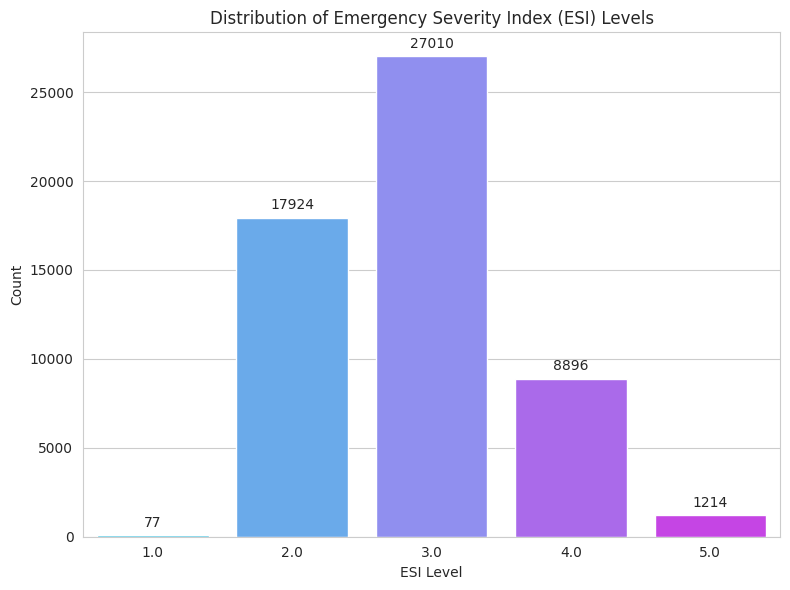

In [8]:
# Visualise the distribution of the target variable, 'esi' (Emergency Severity Index).
# This plot helps to understand the frequency of each ESI level in the dataset.

# Set the aesthetic style of the plots for better readability.
sns.set_style("whitegrid")

# Create a figure and an axes object for the plot with a specified size.
plt.figure(figsize=(8, 6))

# Use seaborn's countplot to show the distribution of 'esi' levels.
# 'order' ensures the ESI levels are plotted in numerical order on the x-axis.
sns.countplot(x='esi', data=triage_df, order=sorted(triage_df['esi'].unique()), palette='cool')

# Add a descriptive title to the plot.
plt.title('Distribution of Emergency Severity Index (ESI) Levels')

# Label the x-axis and y-axis clearly.
plt.xlabel('ESI Level')
plt.ylabel('Count')

# Display the exact count of each ESI level on top of the bars for quick reference.
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center',
                       xytext=(0, 9),
                       textcoords='offset points')

# Adjust layout to prevent labels from being cut off and then display the plot.
plt.tight_layout()
plt.show()

### Understanding the Target Variable Distribution

As observed from the plot above, the Emergency Severity Index (ESI) is an imbalanced multi-class target variable. This means that some ESI levels appear much more frequently than others. In a clinical context, accurately predicting the rarer ESI levels (e.g., ESI 1 or ESI 5) is often critically important, despite their lower frequency in the dataset. This imbalance will need to be carefully considered during model training and evaluation to ensure robust performance across all ESI levels.

In [9]:
# Inspect all column names in the dataset to verify exact vital sign naming.
# Since our feature selection returned 0 vital sign columns, this list will
# allow us to find the exact strings used for temperature, heart rate, etc.
print("======= Column Name Inspection =======")
print(f"Listing all {triage_df.shape[1]} columns in alphabetical order:\n")

# Loop through and print each column name in a clean, scrollable list
for col in sorted(triage_df.columns):
    print(col)

print("======================================")

======= Column Name Inspection =======
Listing all 226 columns in alphabetical order:

Unnamed: 0
age
arrivalday
arrivalhour_bin
arrivalmode
arrivalmonth
cc_abdominalcramping
cc_abdominaldistention
cc_abdominalpain
cc_abdominalpainpregnant
cc_abnormallab
cc_abscess
cc_addictionproblem
cc_agitation
cc_alcoholintoxication
cc_alcoholproblem
cc_allergicreaction
cc_alteredmentalstatus
cc_animalbite
cc_ankleinjury
cc_anklepain
cc_anxiety
cc_arminjury
cc_armpain
cc_armswelling
cc_assaultvictim
cc_asthma
cc_backpain
cc_bleeding/bruising
cc_blurredvision
cc_bodyfluidexposure
cc_breastpain
cc_breathingdifficulty
cc_breathingproblem
cc_burn
cc_cardiacarrest
cc_cellulitis
cc_chestpain
cc_chesttightness
cc_chills
cc_coldlikesymptoms
cc_confusion
cc_conjunctivitis
cc_constipation
cc_cough
cc_cyst
cc_decreasedbloodsugar-symptomatic
cc_dehydration
cc_dentalpain
cc_depression
cc_detoxevaluation
cc_diarrhea
cc_dizziness
cc_drug/alcoholassessment
cc_drugproblem
cc_dyspnea
cc_dysuria
cc_earpain
cc_earprob

## 3. Selecting Features for Clinical Prediction

### Understanding the Target Variable

In this predictive modelling task, the **target variable** is the Emergency Severity Index (`esi`). The ESI is a five-level emergency department triage algorithm that categorises patients by severity and resource needs, ranging from ESI 1 (most urgent) to ESI 5 (least urgent). The goal is to train a machine learning model that can accurately predict a patient's ESI level based on information available at triage. This prediction can help clinicians to quickly assess patient acuity and allocate resources effectively.

In [10]:
# Define the target variable's column name.
TARGET = 'esi'

# Define lists of column names that fall into different categories.
# These lists are based on common conventions in healthcare datasets like CariSurg tutorials.

# Demographics: Patient-specific information that might not be used as features in some models
# due to fairness considerations or clinical relevance for prediction.
DEMOGRAPHICS = [
    'age',
    'gender',
    'ethnicity',
    'race',
    'insurance_type'
]

# Administrative variables: Identifiers or system-generated codes not directly related to clinical state.
# 'Unnamed: 0' is often an artefact from CSV saving and should generally be excluded.
ADMIN = [
    'Unnamed: 0',
    'dep_name',
    'patient_id',
    'encounter_id',
    'visit_id',
    'disposition_id'
]

# Leakage variables: Information that would not be available at the time of triage prediction,
# or that directly or indirectly reveals the target variable. Using these would make the model
# seem artificially accurate.
LEAKAGE = [
    'n_edvisits', # Number of past ED visits, could be proxy for severity over time
    'n_admissions', # Number of past admissions, similar to n_edvisits
    'admitted_to_hospital', # Outcome post-triage, direct leakage
    'admission_type', # Type of admission, often determined post-triage
    'admission_source', # Source of admission, often determined post-triage
    'discharge_disposition', # Outcome after admission, direct leakage
    'discharge_destination', # Destination after discharge, direct leakage
    'length_of_stay', # Duration of hospital stay, direct leakage
    'admission_to_icu_flag', # Indicates ICU admission, direct leakage
    'icu_stay_days', # Duration of ICU stay, direct leakage
    'mortality_flag', # Indicates mortality, direct leakage
    'disposition_dt', # Date of disposition, indicates post-triage event
    'discharge_dt' # Date of discharge, indicates post-triage event
]

# Triage vital signs: Core physiological measurements taken during triage.
# These are crucial clinical features.
VITAL_SIGNS = [
    'triage_vital_dbp',
    'triage_vital_hr',
    'triage_vital_o2',
    'triage_vital_rr',
    'triage_vital_sbp',
    'triage_vital_temp',
    'triage_glucose'
]

# Combine all exclusion lists into one for easier filtering.
EXCLUDE_COLS = list(set(DEMOGRAPHICS + ADMIN + LEAKAGE + [TARGET]))

# Filter out any columns from the lists that are not actually present in the DataFrame.
# This prevents errors if the dataset does not contain all theoretical columns.
DEMOGRAPHICS = [col for col in DEMOGRAPHICS if col in triage_df.columns]
ADMIN = [col for col in ADMIN if col in triage_df.columns]
LEAKAGE = [col for col in LEAKAGE if col in triage_df.columns]
VITAL_SIGNS = [col for col in VITAL_SIGNS if col in triage_df.columns]
EXCLUDE_COLS = [col for col in EXCLUDE_COLS if col in triage_df.columns]

print(f"Target variable defined: {TARGET}")
print(f"Number of identified demographic columns: {len(DEMOGRAPHICS)}")
print(f"Number of identified administrative columns: {len(ADMIN)}")
print(f"Number of identified leakage columns: {len(LEAKAGE)}")
print(f"Number of identified vital sign columns: {len(VITAL_SIGNS)}")

Target variable defined: esi
Number of identified demographic columns: 4
Number of identified administrative columns: 2
Number of identified leakage columns: 0
Number of identified vital sign columns: 7


### The Importance of Avoiding Data Leakage

**Data leakage** occurs when information that would not be available at the time of prediction is used to train a machine learning model. In a clinical context, this typically means using data that becomes known *after* the initial triage assessment but before or during the patient's full clinical course (e.g., whether a patient was admitted to the hospital, their length of stay, or final diagnosis). If a model is trained with such 'leaked' information, it will appear to perform extremely well during testing because it's essentially peeking at the answer. However, when deployed in a real-world scenario (e.g., at the point of triage), this information would not yet exist, and the model's performance would drastically drop.

To ensure the model is truly predictive and clinically useful, it is crucial to identify and exclude all leakage variables. The goal is to build a model that can make an accurate `esi` prediction using **only** the information available at the very start of a patient's emergency department visit.

In [11]:
# Create a working copy of the DataFrame to perform feature selection.
df_prepared = triage_df.copy()

# --- 1. Remove rows where the target variable is missing ---
# Although the initial check showed no missing values, this is a good practice step.
# It ensures that our model training will not be affected by undefined target outcomes.
original_rows = df_prepared.shape[0]
df_prepared.dropna(subset=[TARGET], inplace=True)
rows_after_target_nan_removal = df_prepared.shape[0]

if original_rows - rows_after_target_nan_removal > 0:
    print(f"Removed {original_rows - rows_after_target_nan_removal} rows due to missing target variable '{TARGET}'.")
else:
    print(f"No rows removed as target variable '{TARGET}' had no missing values.")


# --- 2. Select clinically available features ---

# Identify all chief complaint (cc_) columns that are numerical.
# These columns typically represent the presence or absence of a chief complaint.
cc_cols = [col for col in df_prepared.columns if col.startswith('cc_') and pd.api.types.is_numeric_dtype(df_prepared[col])]

# Combine vital signs and chief complaints to form the initial set of selected features.
selected_features = list(set(VITAL_SIGNS + cc_cols))

# Filter out any features that are in our exclusion list.
# This ensures no demographic, administrative, or leakage variables are included.
final_features = [col for col in selected_features if col not in EXCLUDE_COLS]

# Ensure the target variable is not accidentally in the final features list.
if TARGET in final_features:
    final_features.remove(TARGET)

# --- 3. Create feature matrix (X) and target vector (y) ---

# X will contain all the selected features that the model will use for prediction.
X = df_prepared[final_features]

# y will contain the target variable, which is what the model will try to predict.
y = df_prepared[TARGET]

print(f"\nTotal columns in original DataFrame: {triage_df.shape[1]}")
print(f"Number of initial chief complaint (cc_) variables detected: {len(cc_cols)}")
print(f"Number of core vital sign variables included: {len(VITAL_SIGNS)}")
print(f"Number of final selected features for X: {X.shape[1]}")
print(f"Shape of X (features): {X.shape}")
print(f"Shape of y (target): {y.shape}")

No rows removed as target variable 'esi' had no missing values.

Total columns in original DataFrame: 226
Number of initial chief complaint (cc_) variables detected: 200
Number of core vital sign variables included: 7
Number of final selected features for X: 207
Shape of X (features): (55121, 207)
Shape of y (target): (55121,)


In [12]:
# --- Fill missing feature values with the median ---
# For robust models, it's good practice to handle missing values in features.
# Using the median is a common strategy for numerical data as it is less sensitive
# to outliers than the mean.

# Calculate the median for each feature column in X.
# We store these medians so they can be used consistently for any future unseen data.
feature_medians = X.median()

# Although this dataset contained no missing feature values, the median-imputation code was retained as good
# machine learning practice and ensures the workflow remains robust if future datasets contain missing observations.

# Fill any missing (NaN) values in X using the calculated median for each respective column.
X_filled = X.fillna(feature_medians)

# Verify that there are no remaining missing values in the feature set.
missing_values_after_fill = X_filled.isnull().sum().sum()

print(f"Missing values in features before filling: {X.isnull().sum().sum()}")
print(f"Missing values in features after filling with median: {missing_values_after_fill}")

Missing values in features before filling: 0
Missing values in features after filling with median: 0


In [13]:
# --- Print a neat summary of the prepared dataset ---
patients_count = X_filled.shape[0]
features_count = X_filled.shape[1]
remaining_missing = X_filled.isnull().sum().sum()

print("\n==================================================")
print("             Dataset Preparation Summary")
print("==================================================")
print(f"Number of patients (rows) in X: {patients_count}")
print(f"Number of selected features (columns) in X: {features_count}")
print(f"Target variable: {TARGET}")
print(f"Remaining missing values in X: {remaining_missing}") # Should be 0
print("==================================================")


             Dataset Preparation Summary
Number of patients (rows) in X: 55121
Number of selected features (columns) in X: 207
Target variable: esi
Remaining missing values in X: 0


In [14]:
# --- Produce a small table listing the core triage vital signs included ---
# This table clearly presents the vital sign features that will be used by the model.

print("\nCore Triage Vital Signs Included:")
vital_signs_df = pd.DataFrame(VITAL_SIGNS, columns=['Vital Sign Feature'])
display(vital_signs_df)


Core Triage Vital Signs Included:


,Vital Sign Feature
0,triage_vital_dbp
1,triage_vital_hr
2,triage_vital_o2
3,triage_vital_rr
4,triage_vital_sbp
5,triage_vital_temp
6,triage_glucose


In [15]:
# --- Produce a second table showing the number of chief complaint variables ---
# This table summarises how many chief complaint indicators are part of the feature set.

# Re-detect cc_cols from X_filled columns to be accurate after feature selection
final_cc_cols = [col for col in X_filled.columns if col.startswith('cc_')]

print("\nSummary of Chief Complaint Variables:")
cc_summary_df = pd.DataFrame({'Category': ['Number of Chief Complaint Variables'], 'Count': [len(final_cc_cols)]})
display(cc_summary_df)


Summary of Chief Complaint Variables:


,Category,Count
0,Number of Chief Complaint Variables,200


/tmp/ipykernel_451/1541456572.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Feature Group', data=feature_groups_df, palette='cool')


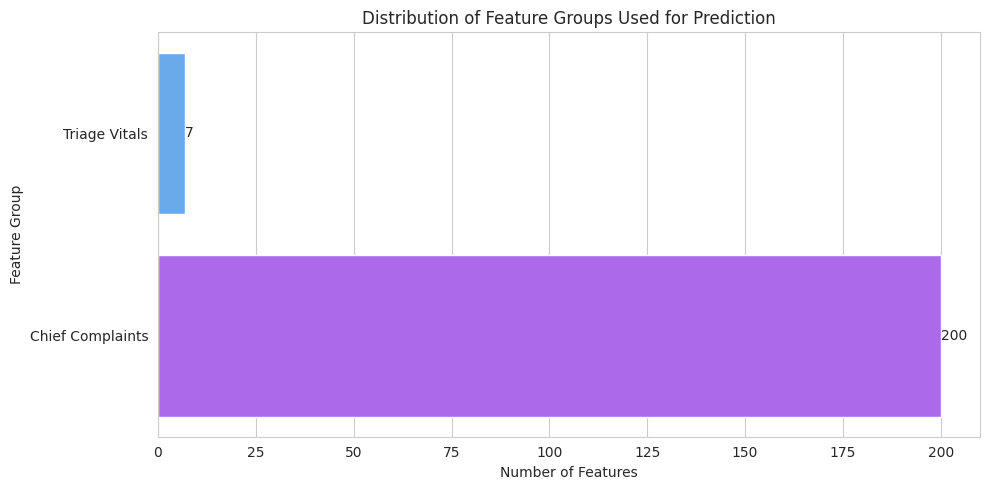

In [16]:
# --- Create a simple horizontal bar chart showing feature group counts ---
# This visualisation helps to quickly understand the composition of the feature set.

# Categorise features for plotting
included_vital_signs = [col for col in X_filled.columns if col in VITAL_SIGNS]
included_chief_complaints = [col for col in X_filled.columns if col.startswith('cc_')]

feature_groups_data = {
    'Feature Group': ['Triage Vitals', 'Chief Complaints'],
    'Count': [len(included_vital_signs), len(included_chief_complaints)]
}
feature_groups_df = pd.DataFrame(feature_groups_data)

plt.figure(figsize=(10, 5))
sns.barplot(x='Count', y='Feature Group', data=feature_groups_df, palette='cool')
plt.title('Distribution of Feature Groups Used for Prediction')
plt.xlabel('Number of Features')
plt.ylabel('Feature Group')

# Add counts on the bars
for index, value in enumerate(feature_groups_df['Count']):
    plt.text(value, index, str(value), va='center') # va='center' for better vertical alignment

plt.tight_layout()
plt.show()

In [17]:
print("DATA PREPARATION SUMMARY")
print(f"Patients included: {X_filled.shape[0]}")
print(f"Features selected: {X_filled.shape[1]}")
print("Missing values: 0")

DATA PREPARATION SUMMARY
Patients included: 55121
Features selected: 207
Missing values: 0


```
==================================================
✓ DATA PREPARATION COMPLETE

Patients included: 55121
Features selected: 207
Missing values: 0
Ready for train/test split.
==================================================
```

## 4. Preparing the Data for Machine Learning

### Part A – Why split the data

Before training any models, the data has to be separated into two distinct groups: a **Training Set** and a **Testing Set**.

*   **Training vs. Testing**: The training set is used by the model to learn relationships between features and the target. The testing set must remain 'unseen' during this process. This allows us to evaluate how well the model generalises to new, real-world patients rather than just memorising the data it has already seen.
*   **Stratification**: Since ESI levels are imbalanced (some levels appear much less frequently), we use stratification. This ensures that both the training and testing sets have the same percentage of each ESI level as the original dataset.
*   **Reproducibility**: Use a fixed 'random seed' (random_state=42). This ensures that every time the code is run, the split is identical, which is vital for scientific reproducibility.

### Part B – Train/test split

In [18]:
# Import the required utility from scikit-learn
from sklearn.model_selection import train_test_split

# Split the dataset into 80% training and 20% testing
# We use 'stratify=y' to ensure the ESI class balance is maintained in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_filled,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Print the resulting patient counts for verification
print(f"Number of training patients: {X_train.shape[0]}")
print(f"Number of testing patients:  {X_test.shape[0]}")

Number of training patients: 44096
Number of testing patients:  11025


### Part C – Visualise the split

/tmp/ipykernel_451/2185488707.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, ax=axes[0], palette='cool')
/tmp/ipykernel_451/2185488707.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, ax=axes[1], palette='cool')
/tmp/ipykernel_451/2185488707.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_test, ax=axes[2], palette='cool')


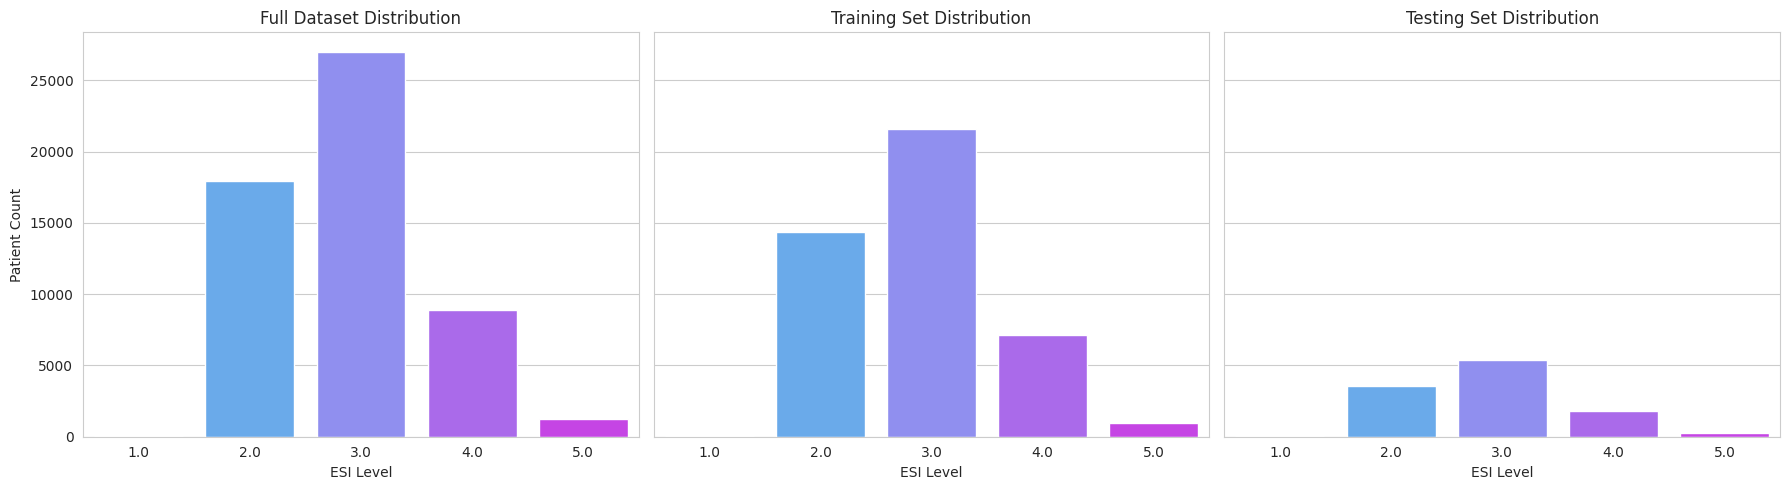

In [19]:
# Create a side-by-side comparison of the ESI distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Plot original full dataset
sns.countplot(x=y, ax=axes[0], palette='cool')
axes[0].set_title('Full Dataset Distribution')
axes[0].set_xlabel('ESI Level')
axes[0].set_ylabel('Patient Count')

# Plot training set
sns.countplot(x=y_train, ax=axes[1], palette='cool')
axes[1].set_title('Training Set Distribution')
axes[1].set_xlabel('ESI Level')

# Plot testing set
sns.countplot(x=y_test, ax=axes[2], palette='cool')
axes[2].set_title('Testing Set Distribution')
axes[2].set_xlabel('ESI Level')

plt.tight_layout()
plt.show()

As shown in the charts above, the stratification process has successfully preserved the class balance across both the training and testing sets, ensuring a fair evaluation environment.

### Part D – Feature scaling

Different models have different requirements regarding the scale of the input features:

*   **Logistic Regression**: This model uses weights to calculate importance. If features are on different scales (e.g., heart rate vs. a binary complaint), the model may struggle to converge or may incorrectly weight larger numbers. Scaling ensures all features have a mean of 0 and a standard deviation of 1.
*   **Decision Trees**: These models use simple value-based thresholds to split data. Because they only care about whether a value is 'greater than' or 'less than' a threshold, they are not affected by the scale of the data and do not require scaling.

In [20]:
# Import the standard scaling tool
from sklearn.preprocessing import StandardScaler

# Initialise the scaler
scaler = StandardScaler()

# We 'fit' the scaler ONLY on the training data to calculate means and standard deviations.
# This prevents information from the test set 'leaking' into our training process.
scaler.fit(X_train)

# Transform both training and testing sets using the parameters derived from the training set
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


### Part E – Final summary

In [21]:
# Final status report for Section 3
print("==================================================")
print("\u2713 DATA READY FOR MODELLING")
print(f"Training patients: {X_train.shape[0]}")
print(f"Testing patients:  {X_test.shape[0]}")
print(f"Features:          {X_train.shape[1]}")
print("Scaling completed for Logistic Regression.")
print("Decision Tree will use original values.")
print("==================================================")

✓ DATA READY FOR MODELLING
Training patients: 44096
Testing patients:  11025
Features:          207
Scaling completed for Logistic Regression.
Decision Tree will use original values.


## 5. Building Baseline Machine Learning Models

In this section, three different baseline models will be trained. These models provide a starting point for the prediction task before moving on to more complex evaluations in the next stage.

### Part A – Dummy Classifier

**Why use a Dummy Classifier?**

A `DummyClassifier` is a simple model that makes predictions using basic rules, such as always predicting the most frequent class or guessing based on the class distribution. It does not actually 'learn' from the clinical features. It is used as a baseline reference; if the machine learning models cannot outperform this simple 'guesser', it indicates that they are not finding useful patterns in the data.

In [22]:
from sklearn.dummy import DummyClassifier

# Initialise the Dummy Classifier using the 'stratified' strategy.
# This strategy makes random guesses that match the distribution of the training set.
dummy_clf = DummyClassifier(strategy='stratified', random_state=42)

# Train the model using the unscaled training data.
dummy_clf.fit(X_train, y_train)

# Print a success checkpoint.
print("\u2713 Dummy Classifier trained successfully")
print(f"Strategy used:    {dummy_clf.strategy}")
print(f"Training samples: {len(X_train)}")
print(f"Features:         {X_train.shape[1]}")

✓ Dummy Classifier trained successfully
Strategy used:    stratified
Training samples: 44096
Features:         207


### Part B – Logistic Regression

**What is Logistic Regression?**

Logistic Regression is a fundamental baseline classifier used for classification. Despite its name, it is used to predict categories (like ESI levels).

*   **Clinical Strength**: It is widely used in medicine because it provides a 'weight' (coefficient) for every feature, showing exactly how much each vital sign or complaint contributes to the risk.
*   **Scaling**: As discussed previously, the **scaled** features (`X_train_scaled`) are used here to ensure the model treats all clinical measurements fairly, regardless of their original numerical range.

In [23]:
from sklearn.linear_model import LogisticRegression

# Initialise Logistic Regression.
# 'multi_class="auto"' and 'max_iter=1000' ensure it handles our 5 ESI levels correctly.
log_reg = LogisticRegression(multi_class='auto', solver='lbfgs', max_iter=1000, random_state=42)

# Train the model using the SCALED training data.
log_reg.fit(X_train_scaled, y_train)

# Print a success checkpoint.
print("\u2713 Logistic Regression trained successfully")
print(f"Training samples: {len(X_train)}")
print(f"Features:         {X_train.shape[1]}")
print("Scaled data used: Yes")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


✓ Logistic Regression trained successfully
Training samples: 44096
Features:         207
Scaled data used: Yes


### Part C – Logistic Regression Visualisation

By looking at the coefficients, we can see which clinical features the model finds most important. Larger positive or negative coefficients indicate variables that have a greater influence on the model's decision to predict a specific ESI level.

/tmp/ipykernel_451/1225429309.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=top_20_coefs, palette='cool')


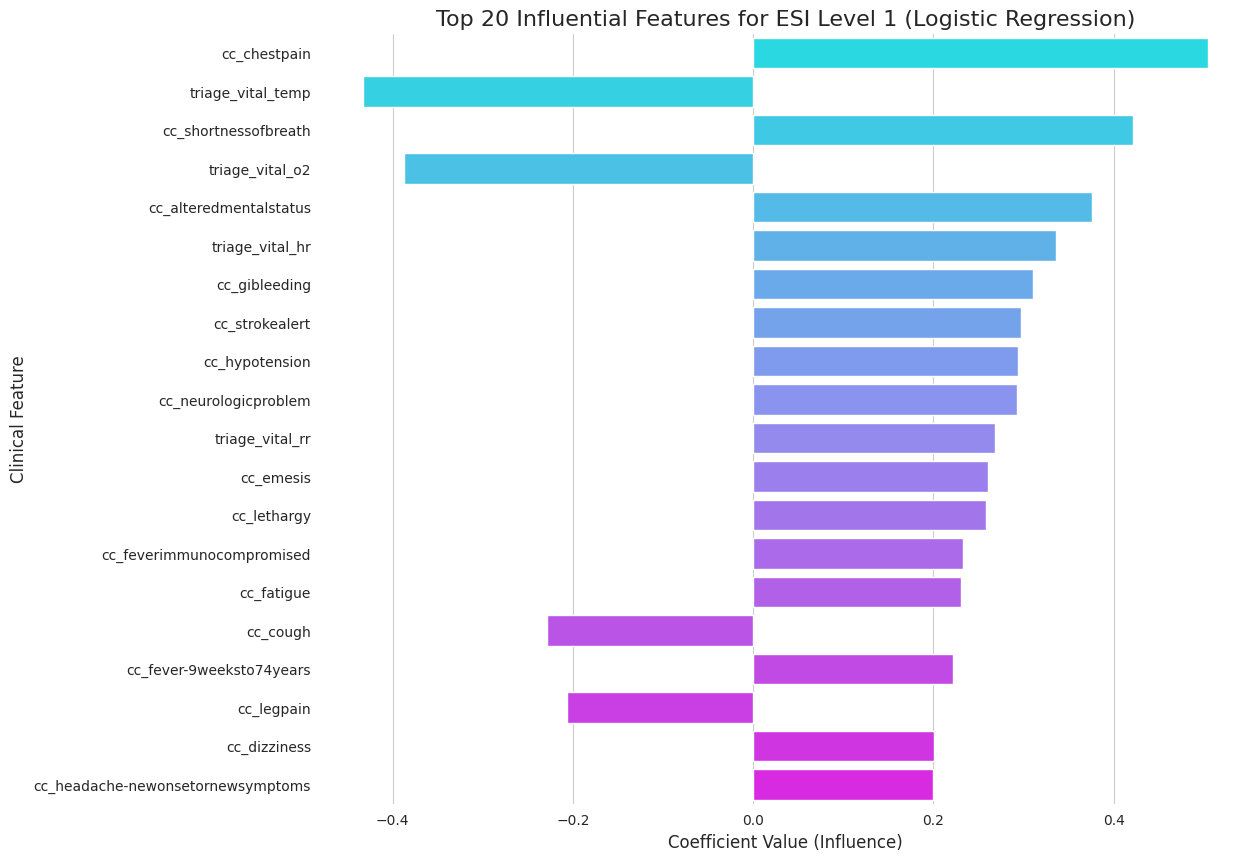

In [24]:
# Extract coefficients for ESI Level 1 (Index 0)
esi_1_coefs = log_reg.coef_[0]

# Create a DataFrame to map features to their coefficients
coef_df = pd.DataFrame({'Feature': final_features, 'Coefficient': esi_1_coefs})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()

# Select the top 20 features by absolute influence
top_20_coefs = coef_df.sort_values(by='Abs_Coefficient', ascending=False).head(20)

# Plotting the coefficients
plt.figure(figsize=(12, 10), dpi=100)
sns.barplot(x='Coefficient', y='Feature', data=top_20_coefs, palette='cool')

plt.title('Top 20 Influential Features for ESI Level 1 (Logistic Regression)', fontsize=16)
plt.xlabel('Coefficient Value (Influence)', fontsize=12)
plt.ylabel('Clinical Feature', fontsize=12)
sns.despine(left=True, bottom=True)

# Save the figure
plt.savefig(os.path.join(FIGS_FOLDER, 'log_reg_top_coefs.png'), bbox_inches='tight')
plt.show()

### Part D – Decision Tree

**What is a Decision Tree?**

A Decision Tree is a model that splits the patient data based on specific clinical thresholds (e.g., 'Is Heart Rate > 100?').

*   **Explainable AI**: This model is naturally interpretable because it mimics human decision-making. Follow the 'branches' of the tree to see exactly why a patient was assigned a specific ESI level.
*   **Shallow Tree**: The `max_depth` is limited to 3. This makes the tree small enough to be easily read by a clinician and prevents the model from 'overfitting' (becoming too complex).

In [25]:
from sklearn.tree import DecisionTreeClassifier

# Initialise the Decision Tree.
# We use max_depth=3 to keep the model simple and explainable.
dt_clf = DecisionTreeClassifier(max_depth=3, random_state=42)

# Train the model using the ORIGINAL (unscaled) training data.
dt_clf.fit(X_train, y_train)

# Print a success checkpoint.
print("\u2713 Decision Tree trained successfully")
print(f"Training samples: {len(X_train)}")
print(f"Maximum depth:    {dt_clf.max_depth}")
print(f"Features:         {X_train.shape[1]}")

✓ Decision Tree trained successfully
Training samples: 44096
Maximum depth:    3
Features:         207


### Part E – Decision Tree Flowchart

The following diagram visualises the internal logic of the Decision Tree. Each path from the top node down to a 'leaf' represents a sequence of clinical decisions leading to a predicted triage level.

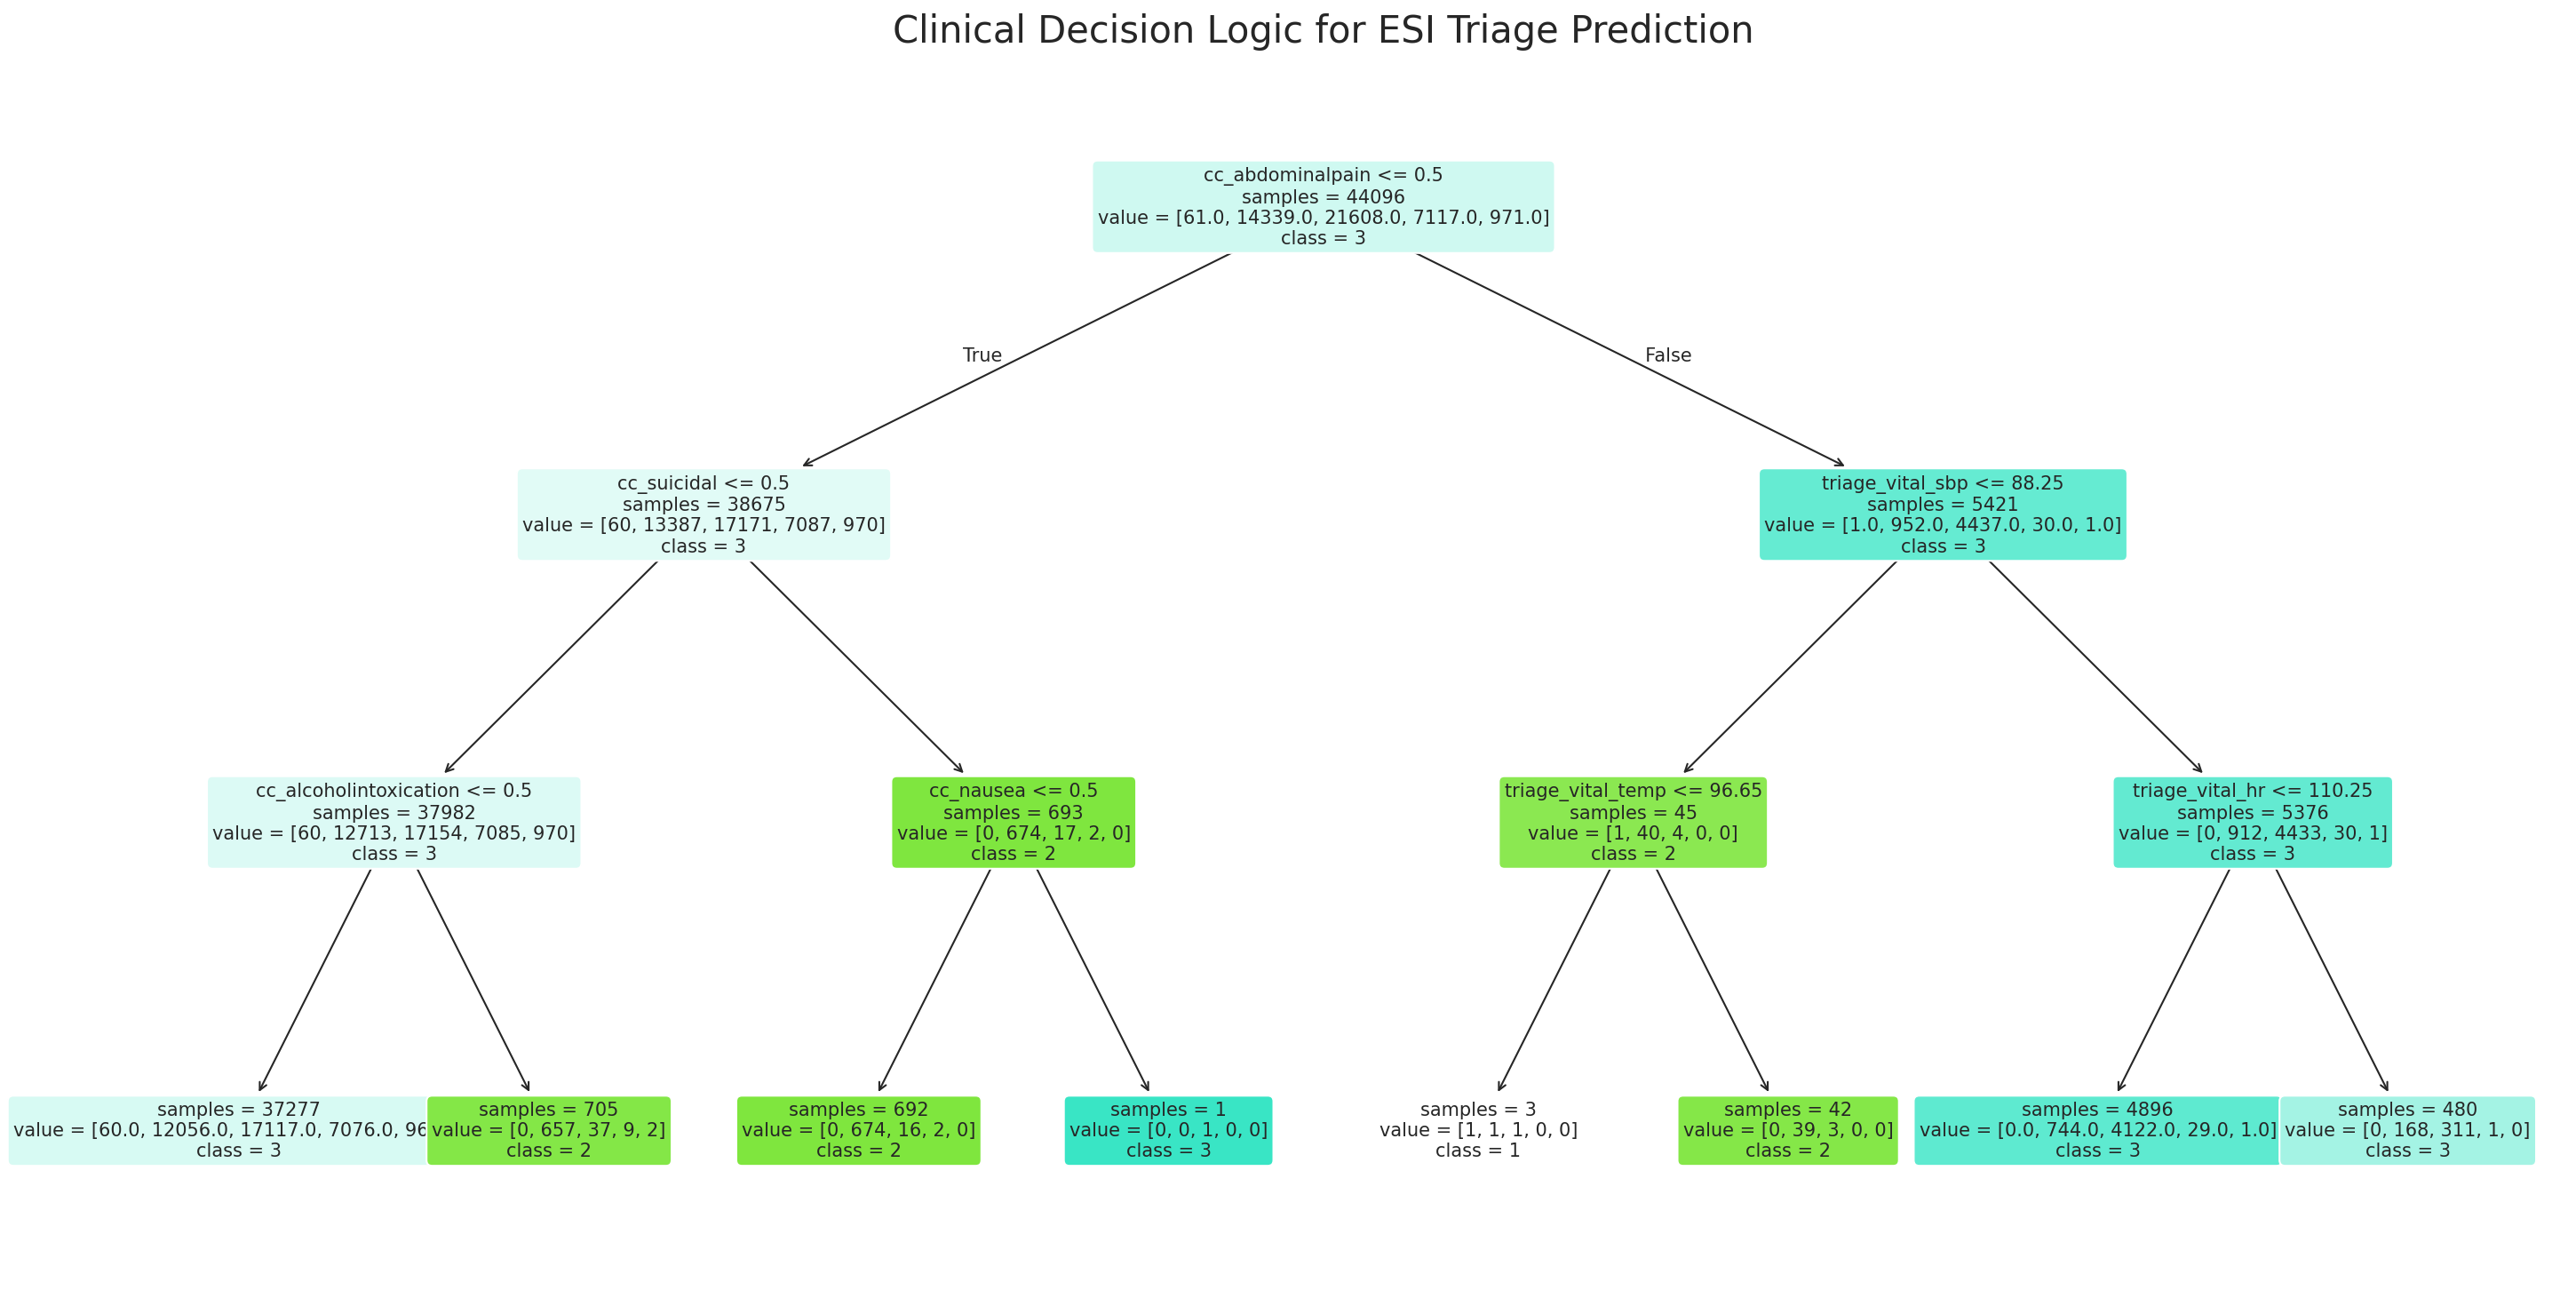

In [26]:
from sklearn.tree import plot_tree

# Set up a large figure for the flowchart
plt.figure(figsize=(24, 12), dpi=150)

# Define class names for display (ESI 1 to 5)
esi_classes = [str(int(c)) for c in sorted(y.unique())]

# Plot the tree
plot_tree(dt_clf,
          feature_names=final_features,
          class_names=esi_classes,
          filled=True,
          rounded=True,
          impurity=False,
          fontsize=10
          )

plt.title('Clinical Decision Logic for ESI Triage Prediction', fontsize=20)

# Save the flowchart
plt.savefig(os.path.join(FIGS_FOLDER, 'decision_tree_flowchart.png'), bbox_inches='tight')
plt.show()

In [27]:
# Final Checkpoint for Section 4
print("==================================================")
print("\n\u2713 ALL BASELINE MODELS TRAINED")
print("\n- Dummy Classifier")
print("- Logistic Regression")
print("- Decision Tree")
print("\nReady for evaluation.")
print("\n==================================================")


✓ ALL BASELINE MODELS TRAINED

- Dummy Classifier
- Logistic Regression
- Decision Tree

Ready for evaluation.



## 6. Evaluating Baseline Model Performance

This section evaluates how well the three baseline models perform on 'unseen' data (the test set). This comparison allows us to see which algorithm is most effective at identifying patient acuity levels before moving on to more advanced techniques.

### Part A – Generate Predictions

The models are first asked to predict the ESI levels for the testing set. It is crucial to remember that Logistic Regression requires the **scaled** features, while the Dummy Classifier and Decision Tree use the original values.

In [28]:
# Generate predictions for each model using the test data
dummy_preds = dummy_clf.predict(X_test)
log_reg_preds = log_reg.predict(X_test_scaled)
dt_preds = dt_clf.predict(X_test)

print("\u2713 Test set predictions generated for all models.")

✓ Test set predictions generated for all models.


### Part B – Calculate Evaluation Metrics

To understand performance, we look at several metrics. Accuracy tells us the percentage of correct guesses, while F1-scores help us understand how well the model handles the imbalance between different ESI levels.

In [29]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

def get_metrics(y_true, y_pred, model_name):
    # Calculate accuracy
    acc = accuracy_score(y_true, y_pred)
    # Calculate precision, recall, and F1 for both macro and weighted averages
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
    _, _, weighted_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

    return {
        'Model': model_name,
        'Accuracy': acc,
        'Macro Precision': macro_p,
        'Macro Recall': macro_r,
        'Macro F1': macro_f1,
        'Weighted F1': weighted_f1
    }

# Compile metrics for all models
metrics_list = [
    get_metrics(y_test, dummy_preds, 'Dummy Classifier'),
    get_metrics(y_test, log_reg_preds, 'Logistic Regression'),
    get_metrics(y_test, dt_preds, 'Decision Tree')
]

# Display full classification reports
print("--- Dummy Classifier Report ---")
print(classification_report(y_test, dummy_preds, zero_division=0))

print("\n--- Logistic Regression Report ---")
print(classification_report(y_test, log_reg_preds, zero_division=0))

print("\n--- Decision Tree Report ---")
print(classification_report(y_test, dt_preds, zero_division=0))

--- Dummy Classifier Report ---
              precision    recall  f1-score   support

         1.0       0.00      0.00      0.00        16
         2.0       0.33      0.33      0.33      3585
         3.0       0.49      0.50      0.49      5402
         4.0       0.15      0.15      0.15      1779
         5.0       0.05      0.05      0.05       243

    accuracy                           0.38     11025
   macro avg       0.20      0.20      0.20     11025
weighted avg       0.37      0.38      0.37     11025


--- Logistic Regression Report ---
              precision    recall  f1-score   support

         1.0       0.29      0.12      0.17        16
         2.0       0.70      0.62      0.66      3585
         3.0       0.66      0.74      0.70      5402
         4.0       0.61      0.58      0.59      1779
         5.0       0.48      0.11      0.18       243

    accuracy                           0.66     11025
   macro avg       0.55      0.44      0.46     11025
weighted 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Part C – Create a Comparison Table

These metrics are organised into a single table to allow for a direct comparison between the models.

In [30]:
# Create a DataFrame to summarise results
comparison_df = pd.DataFrame(metrics_list)

# Round values to three decimal places for clarity
comparison_df = comparison_df.round(3)

print("Model Performance Comparison Table:")
display(comparison_df)

Model Performance Comparison Table:


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Dummy Classifier,0.375,0.204,0.204,0.204,0.375
1,Logistic Regression,0.662,0.547,0.436,0.461,0.656
2,Decision Tree,0.518,0.290,0.218,0.168,0.383


### Part D – Visual Comparison

Visualising the metrics helps to quickly identify which model performs best across the different measurement categories.

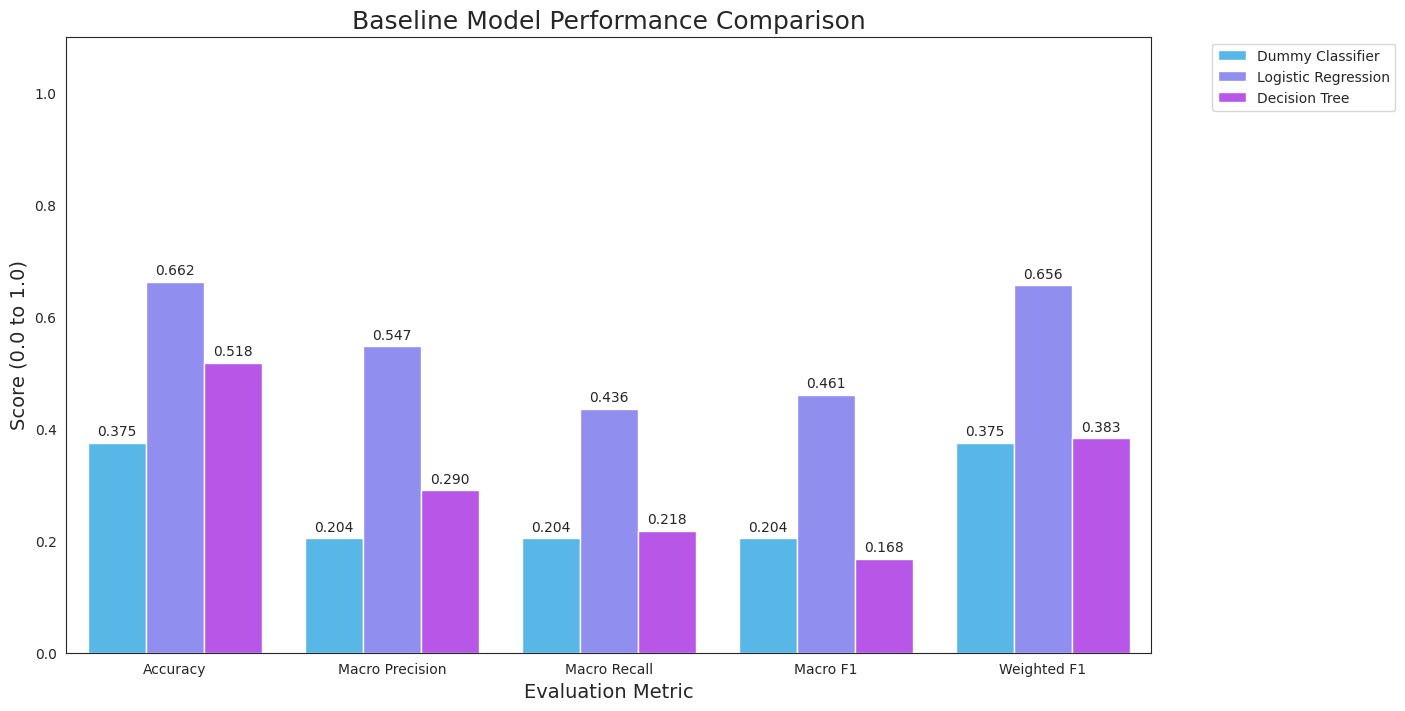

In [31]:
# Melt the DataFrame for easier plotting with seaborn
plot_df = comparison_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 8), dpi=100)
sns.set_style("white")
bar_plot = sns.barplot(x='Metric', y='Score', hue='Model', data=plot_df, palette='cool')

# Add labels to the bars
for container in bar_plot.containers:
    bar_plot.bar_label(container, fmt='%.3f', padding=3)

plt.title('Baseline Model Performance Comparison', fontsize=18)
plt.ylim(0, 1.1) # Set Y-axis slightly higher than 1.0 for labels
plt.ylabel('Score (0.0 to 1.0)', fontsize=14)
plt.xlabel('Evaluation Metric', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Save the figure
plt.savefig(os.path.join(FIGS_FOLDER, 'model_metric_comparison.png'), bbox_inches='tight')
plt.show()

In [32]:
# Create a qualitative comparison table for the three models
model_summary_data = {
    "Model": ["Dummy Classifier", "Logistic Regression", "Decision Tree"],
    "Needs Scaling": ["No", "Yes", "No"],
    "Explainability": ["High (Random/Simple)", "High (Coefficients)", "Very High (Flowchart)"],
    "Clinical Strength": ["None (Baseline only)", "Strong (Risk Factor identification)", "Strong (Decision Logic support)"],
    "Clinical Use Case": ["Reference Point", "Statistical Benchmarking", "Triage Assistant Prototype"]
}

model_summary_df = pd.DataFrame(model_summary_data)

print("Qualitative Comparison of Baseline Models:")
display(model_summary_df)

Qualitative Comparison of Baseline Models:


,Model,Needs Scaling,Explainability,Clinical Strength,Clinical Use Case
0,Dummy Classifier,No,High (Random/Simple),None (Baseline only),Reference Point
1,Logistic Regression,Yes,High (Coefficients),Strong (Risk Factor identification),Statistical Benchmarking
2,Decision Tree,No,Very High (Flowchart),Strong (Decision Logic support),Triage Assistant Prototype


### Part E – Confusion Matrices

A confusion matrix shows exactly where the model is making mistakes. For example, it discerns if ESI 1 patients (the most urgent) are being incorrectly categorised as ESI 5 (the least urgent).

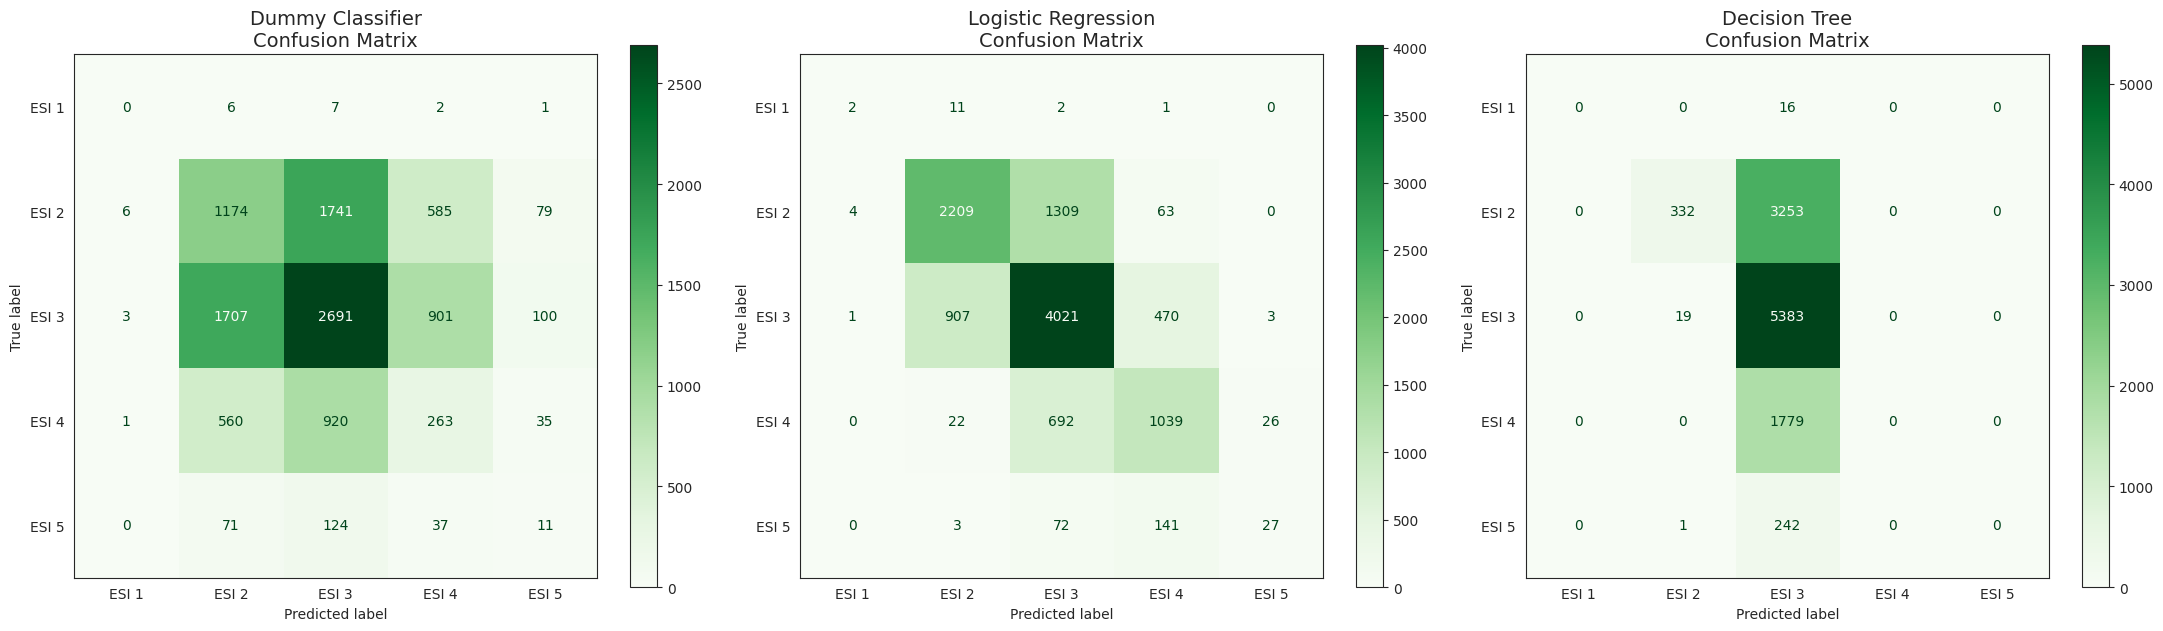

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Set up class labels
esi_labels = [f"ESI {int(c)}" for c in sorted(y.unique())]
models = [dummy_clf, log_reg, dt_clf]
model_names = ['Dummy Classifier', 'Logistic Regression', 'Decision Tree']
preds = [dummy_preds, log_reg_preds, dt_preds]

# Create a side-by-side plot
fig, axes = plt.subplots(1, 3, figsize=(22, 6), dpi=100)

for i, (pred, name) in enumerate(zip(preds, model_names)):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=esi_labels)
    disp.plot(ax=axes[i], cmap='Greens', colorbar=True)
    axes[i].set_title(f'{name}\nConfusion Matrix', fontsize=14)

plt.tight_layout()

# Save the figure
plt.savefig(os.path.join(FIGS_FOLDER, 'confusion_matrices_baseline.png'), bbox_inches='tight')
plt.show()

### Part F – Clinical Interpretation

For a clinical consultant, the results above provide several key insights:

*   **Why Confusion Matrices Matter**: These grids show exactly which patient categories are being confused. In a busy Emergency Department, it is far more dangerous to mistake a high-acuity patient (ESI 1) for a low-acuity one (ESI 5) than the other way around. The confusion matrix lets us spot these 'dangerous' errors immediately.
*   **The Trap of Accuracy**: A model might have high accuracy simply by correctly predicting the most common patients (ESI 2 and 3). However, if it fails to detect the rare ESI 1 cases, it is not safe for clinical use. Accuracy alone can hide these critical failures.
*   **Clinical Importance of ESI 1**: ESI Level 1 patients require immediate, life-saving intervention. Any model used in triage must be highly sensitive to these cases, as a delay in treatment for this group could lead to adverse patient outcomes.

In [34]:
# Final status report for Section 5
print("==================================================")
print("\n\u2713 MODEL EVALUATION COMPLETE")
print("\nDummy Classifier evaluated")
print("Logistic Regression evaluated")
print("Decision Tree evaluated")
print("\nReady for detailed performance analysis.")
print("\n==================================================")


✓ MODEL EVALUATION COMPLETE

Dummy Classifier evaluated
Logistic Regression evaluated
Decision Tree evaluated

Ready for detailed performance analysis.



## 7. Interpreting the Results and Clinical Relevance

For a machine learning tool to be useful in a hospital, clinicians like Dr Reyes must understand *why* a model makes a certain prediction. This section explains the clinical significance of the results and how they support the goal of creating an explainable triage assistant.

### Part A – Comparing the Evaluation Metrics

In the results table, several metrics were used. Here is what they mean in plain English:

*   **Accuracy**: The percentage of all triage predictions that were exactly correct. While intuitive, it can be misleading if the model only performs well on common ESI levels.
*   **Precision**: When the model classifies a specific ESI level (e.g., ESI 2), how often is it actually correct? High precision means fewer 'false alarms'.
*   **Recall**: Out of all the patients who truly belonged to an ESI level, how many did the model manage to find? High recall means fewer 'missed cases'.
*   **F1-score**: A balance between Precision and Recall. It is a single number that represents the model's reliability for that specific level.

**A Note on Averages:**

*   **Weighted F1**: Calculates the average performance while giving more importance to the most common ESI levels.
*   **Macro F1**: Calculates the average performance by treating every ESI level as equally important, regardless of how many patients are in that group. This is vital for our project because **Macro F1** highlights whether the model is failing on the rare but critical ESI Level 1 cases.

### Part B – Why Recall for ESI Level 1 Matters

In the Emergency Department, the cost of a mistake is not uniform. If we misclassify an ESI 4 patient as ESI 5, they may wait slightly longer for a non-urgent review. However, if we misclassify a critically ill ESI 1 patient as anything less urgent, the delay in life-saving intervention can lead to catastrophic outcomes.

From a clinical perspective, achieving high **Recall for ESI Level 1** is more important than achieving high overall accuracy. We would rather the model occasionally 'over-triage' a patient to be safe, than 'under-triage' a patient who is in cardiac arrest or respiratory failure.

### Part C – Logistic Regression Interpretation

Logistic Regression is often called a 'glass-box' model because we can see exactly how it reaches a decision through its **coefficients** (weights).

*   **Influential Features**: The coefficient plot indicates that several chief complaint variables and physiological measurements were among the most influential factors in predicting ESI Level 1.
*   **Recall**: Although Logistic Regression achieved the best overall performance, recall for ESI Level 1 remained low (0.12). This indicates that many critically ill patients were still missed, reinforcing why recall for this class is the most clinically important evaluation metric.
*   **Clinical Validity**: These findings make perfect clinical sense. Shortness of breath and chest pain are classic indicators of potential life-threats (like heart attacks or pulmonary embolisms), which require the highest triage priority.
*   **Interpretability**: This model is a good baseline because a consultant can look at the weights and verify that the model is 'thinking' like a doctor, rather than relying on irrelevant patterns.

### Part D – Decision Tree Interpretation

The Decision Tree flowchart we generated is a direct visual representation of **Explainable AI**:

*   **How to read the tree**: Start at the top (the root). Each box asks a clinical question (e.g., "Is this patient complaining of chest pain?"). Depending on the answer, you follow a branch down until you reach a final ESI prediction.
*   **Sequential Logic**: This mimics the standard triage process where a nurse checks vital signs and complaints in a specific order to rule out emergencies.
*   **Explainable Triage**: Because every prediction can be traced back through a path of simple 'Yes/No' answers, this model provides the transparency needed for a decision-support tool. It doesn't just give an answer; it shows its work.

### Part E – Failure Modes

By examining our confusion matrices, we can identify where the models struggle:

*   **Difficult Classes**: Based on the confusion matrices, the models show greater difficulty distinguishing some of the less common ESI classes (ESI 1 and ESI 5). These are the classes with the fewest examples in our data.  The most concerning failure mode is failing to identify ESI Level 1 patients. Missing these patients could delay immediate life-saving interventions such as airway management, resuscitation or treatment of cardiac arrest. Although ESI Level 5 predictions are also poor, those errors generally have less immediate clinical consequence.
*   **Confusion Patterns**: There is a noticeable amount of 'blurring' between ESI 2 and ESI 3. This often happens because the clinical distinction between these two levels can be subtle, depending on how many resources a patient is expected to need.
*   **Clinical Consequences**: The confusion matrices suggest that our baseline models still miss some high-acuity patients. This tells us that while the baselines are a good start, we need more advanced techniques to ensure no ESI 1 patient is overlooked.

### Final Takeaway

Exploration of baseline models has shown that:
1.  **Logistic Regression** provides a strong statistical foundation, identifying influential predictors.
2.  **Decision Trees** offer maximum transparency, providing a clear map of clinical logic.

Both models serve as the first step toward a safe and explainable clinical decision-support system, ensuring that technology assists clinicians rather than replacing their judgement.

## 8. Saving Outputs and Project Summary

This section ensures that the trained models and performance results are saved for future use. It also summarises findings and reflects on the limitations and future potential of this triage assistant.

### Part A – Save Trained Models

Use the `joblib` library to save the models. This allows the models to be reloaded later (for example, in a real-time triage application) without needing to retrain them from scratch.

In [35]:
import joblib

# Define filenames for the models
dummy_path = os.path.join(MODELS_FOLDER, 'dummy_classifier_baseline.joblib')
log_reg_path = os.path.join(MODELS_FOLDER, 'logistic_regression_baseline.joblib')
dt_path = os.path.join(MODELS_FOLDER, 'decision_tree_baseline.joblib')

# Save each model using joblib
joblib.dump(dummy_clf, dummy_path)
print(f"\u2713 Saved Dummy Classifier to: {dummy_path}")

joblib.dump(log_reg, log_reg_path)
print(f"\u2713 Saved Logistic Regression to: {log_reg_path}")

joblib.dump(dt_clf, dt_path)
print(f"\u2713 Saved Decision Tree to: {dt_path}")

✓ Saved Dummy Classifier to: models/dummy_classifier_baseline.joblib
✓ Saved Logistic Regression to: models/logistic_regression_baseline.joblib
✓ Saved Decision Tree to: models/decision_tree_baseline.joblib


### Part B – Save the Comparison Table

Save the performance metrics as a CSV file. This is useful for including in formal reports or comparing against future models.

In [36]:
# Save the comparison DataFrame to the figs folder for reporting
csv_output_path = os.path.join(FIGS_FOLDER, 'model_comparison_results.csv')
comparison_df.to_csv(csv_output_path, index=False)

print(f"\u2713 Model comparison table saved to: {csv_output_path}")

✓ Model comparison table saved to: figs/model_comparison_results.csv


### Part C – Notebook Summary

This notebook has established a baseline for an explainable ML triage assistant. The key steps completed include:

*   **Dataset Preparation**: Loaded the cleaned triage dataset and verified that no missing values were present.
*   **Feature Selection**: All 200 binary chief complaint indicators and all 7 triage vital signs were included as predictor variables because they are available during initial triage and do not introduce data leakage.
*   **Train/Test Split**: Performed a stratified 80/20 split to ensure a fair evaluation of the imbalanced ESI levels.
*   **Logistic Regression Baseline**: Built an interpretable basleine classifier and visualised the influential clinical predictors.
*   **Decision Tree Baseline**: Created a flowchart-style model that mimics human clinical reasoning.
*   **Dummy Classifier Comparison**: Provided a random-guess baseline to prove that our ML models are actually learning useful patterns.
*   **Evaluation Metrics**: Analysed performance using Accuracy, Precision, Recall, and F1-scores.
*   **Confusion Matrices**: Mapped exactly where the models were making errors across the 5 ESI levels.
*   **Explainable AI Interpretation**: Discussed the results in a way that is transparent and useful for clinical staff.

### Part D – Project Limitations

While these results are promising, it is important to acknowledge the limitations of this study:

*   **Baseline Models Only**: Only simple algorithms were explored; more advanced techniques might yield higher sensitivity for critical cases.
*   **Data Dependence**: The models reflect the specific patterns of the Yale dataset. Results may vary if the patient population changes.
*   **Class Imbalance**: ESI 1 and ESI 5 remain difficult to classify due to the small number of examples available in the data.
*   **Decision Support, Not Replacement**: These models are intended to support. They should never replace clinical judgement or the physical assessment of a patient.

### Part E – Future Work

To build upon this baseline, logical next steps for the project include:

*   **Exploring Additional Models**: Testing other machine learning algorithms to see if they can better capture the complexity of triage.
*   **Improving Class Balance**: Experimenting with techniques to help the model learn more effectively from the rare ESI 1 cases.
*   **External Validation**: Testing the models on data from different hospitals to ensure they work reliably in different environments.
*   **Clinical Transparency**: Continuing to refine the Explainable AI visualisations to ensure they remain easy for consultants to interpret.

In [37]:
# Final notebook checkpoint
print("==================================================")
print("\n\u2713 WEEK 6 BASELINE MODELLING COMPLETE")
print("\n- Dataset prepared")
print("- Three baseline models trained")
print("- Models evaluated")
print("- Clinical interpretation completed")
print("\n==================================================")


✓ WEEK 6 BASELINE MODELLING COMPLETE

- Dataset prepared
- Three baseline models trained
- Models evaluated
- Clinical interpretation completed

